In [1]:
import numpy as np
import awkward as ak
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colormaps
from pathlib import Path

import xtrack as xt
import xcoll as xc

In [2]:
line = xt.load('../../injection_lines/sps_with_aperture_inj_q20_beam_sagitta4.json')
env = line.env

Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

Done loading line from dict.           


In [3]:
tunes_scan = [19.9, 19.92, 19.95,  19.96, 19.99, 20.001, 20.01, 20.03, 20.05, 20.07, 20.09, 20.11, 20.13, 20.15, 20.17, 20.19]

In [67]:
c = 0.5
env.vars['qph_setvalue'] = c
env.vars['qpv_setvalue'] = c
qy = 20.18
twisses = {}
for qx in tunes_scan:
    line = xt.load('../../injection_lines/sps_with_aperture_inj_q20_beam_sagitta4.json')
    env = line.env
    print(qx)
    opt = line.match(
        method='6d', # <- passed to twiss
        vary=[
            xt.VaryList(['kqf0', 'kqd0'], step=1e-8, tag='quad'),
            xt.VaryList(['qph_setvalue', 'qpv_setvalue'], step=1e-4, tag='sext'),
        ],
        targets = [
            xt.TargetSet(qx=qx, qy=qy, tol=1e-6, tag='tune'),
            xt.TargetSet(dqx=c*qx, dqy=c*qy, tol=1e-2, tag='chrom'),
        ])
    twisses[qx] = line.twiss(method='6d')

Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

Done loading line from dict.           
19.9
                                             
Optimize - start penalty: 14.29                             
Matching: model call n. 13 penalty = 4.2105e-04              
Optimize - end penalty:  0.000421049                            


Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

Done loading line from dict.           
19.92
                                             
Optimize - start penalty: 14.27                             
Matching: model call n. 13 penalty = 1.7597e-04              
Optimize - end penalty:  0.000175969                            


Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

...

Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

Done loading line from dict.           
19.99
                                             
Optimize - start penalty: 14.21                             
Matching: model call n. 19 penalty = 2.7985e-05              
Optimize - end penalty:  2.79848e-05                            


Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

Done loading line from dict.           
20.001
                                             
Optimize - start penalty: 14.21                             
Matching: model call n. 78 penalty = 4.8714e-01               

Could not find point within tolerance.


Warning! Need second attempt on closed orbit search


Could not find point within tolerance.


Matching: model call n. 87 penalty = 4.7585e-01               

Could not find point within tolerance.


Warning! Need second attempt on closed orbit search


Could not find point within tolerance.


Matching: model call n. 96 penalty = 4.7017e-01               

Could not find point within tolerance.


Warning! Need second attempt on closed orbit search


Could not find point within tolerance.


Matching: model call n. 106 penalty = 4.5684e-01              

Could not find point within tolerance.


Warning! Need second attempt on closed orbit search


Could not find point within tolerance.


Matching: model call n. 116 penalty = 4.4607e-

RuntimeError: Could not find point within tolerance.

KeyError: 19.99

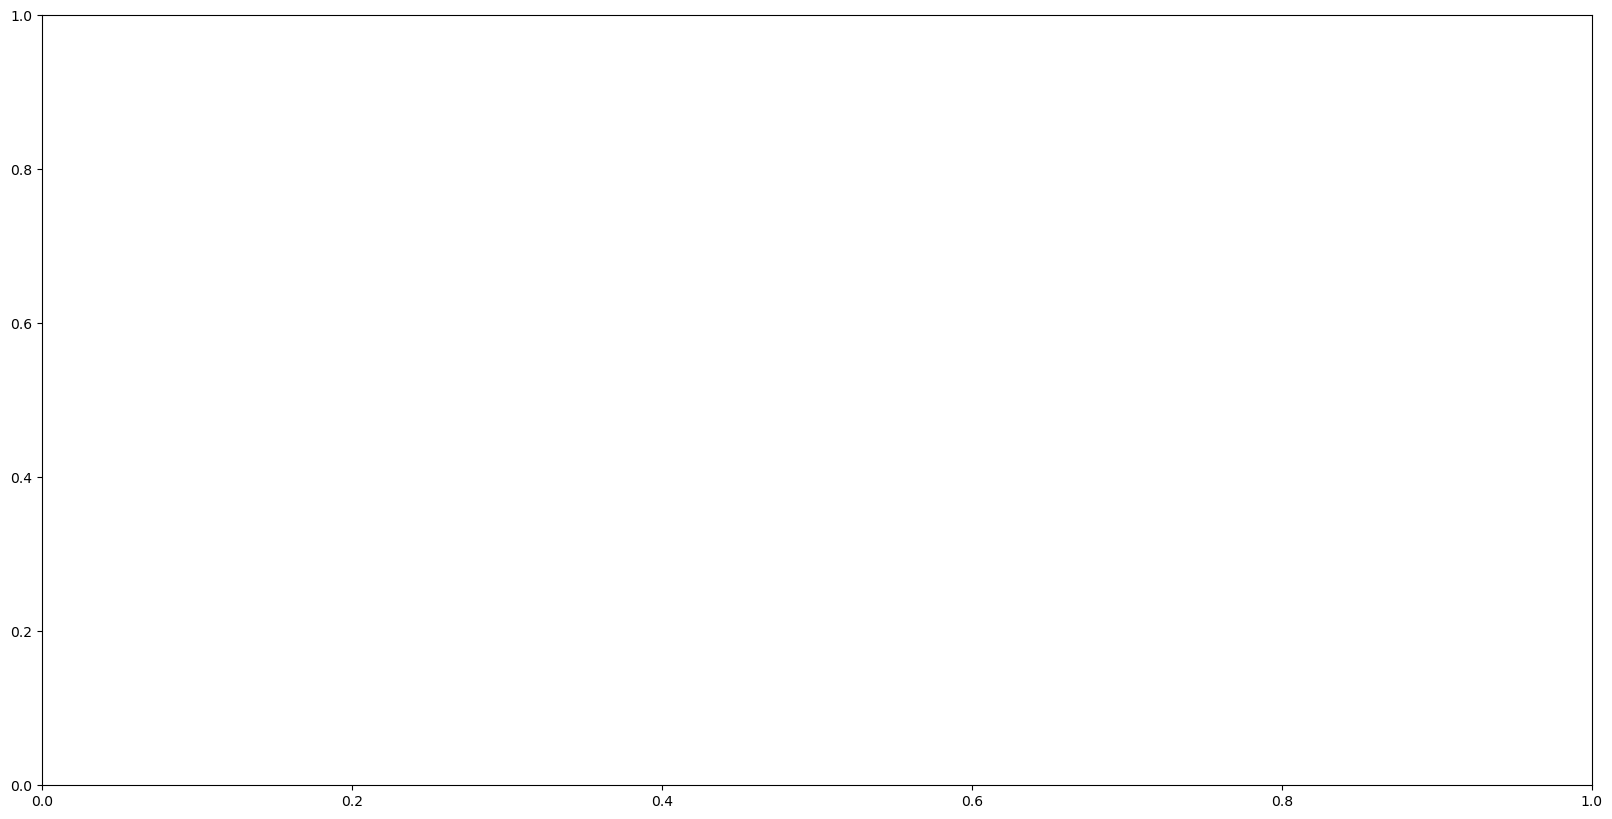

In [65]:
fig, ax = plt.subplots(1,1, figsize=(20,10))
cmap = colormaps['plasma']
tune_min = min(tunes_scan)
tune_max = max(tunes_scan)
norm = plt.Normalize(min(tunes_scan), max(tunes_scan))
# for twiss in twisses.values():
#     ax.plot(twiss.s, twiss.dx, color=cmap(norm(twiss.qx)))
for key in [19.99, 20.008, 20.01, 20.03, 20.05, 20.07, 20.09, 20.11, 20.13, 20.15, 20.17, 20.19]:
    twiss = twisses[key]
    ax.plot(twiss.s, twiss.dx, color=cmap(norm(twiss.qx)), label=f'Qx={twiss.qx:.3f}')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Horizontal tune')
ax.set_xlabel('s [m]')
ax.set_ylabel('Dx [m]')
ax.grid()

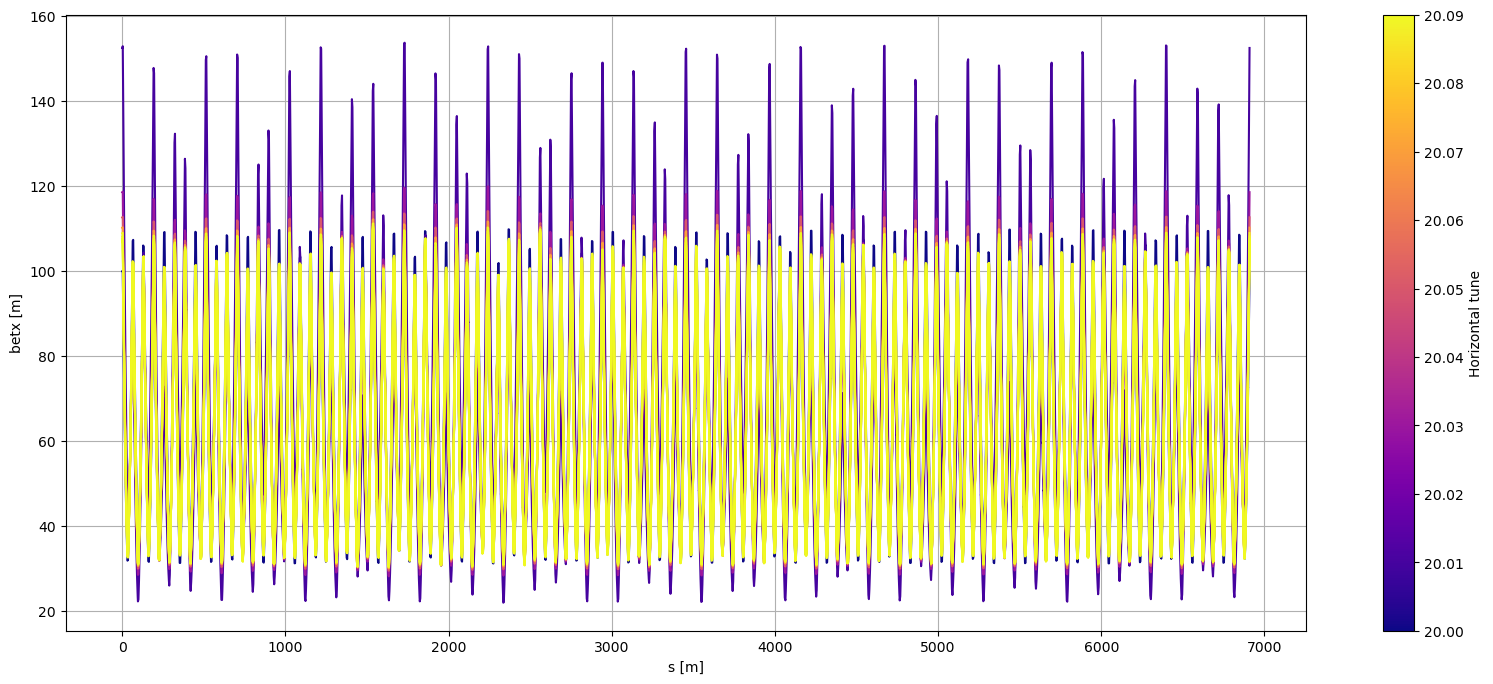

In [36]:
fig, ax = plt.subplots(1,1, figsize=(20,8))
cmap = colormaps['plasma']
tune_min = 20.0#min(tunes_scan)
tune_max = 20.09#max(tunes_scan)
norm = plt.Normalize(tune_min, tune_max)
for key in twisses.keys():#[20.01, 20.03, 20.05, 20.07]:
    twiss = twisses[key]
    ax.plot(twiss.s, twiss.betx, color=cmap(norm(twiss.qx)))

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Horizontal tune')
ax.set_xlabel('s [m]')
ax.set_ylabel('betx [m]')
ax.grid()

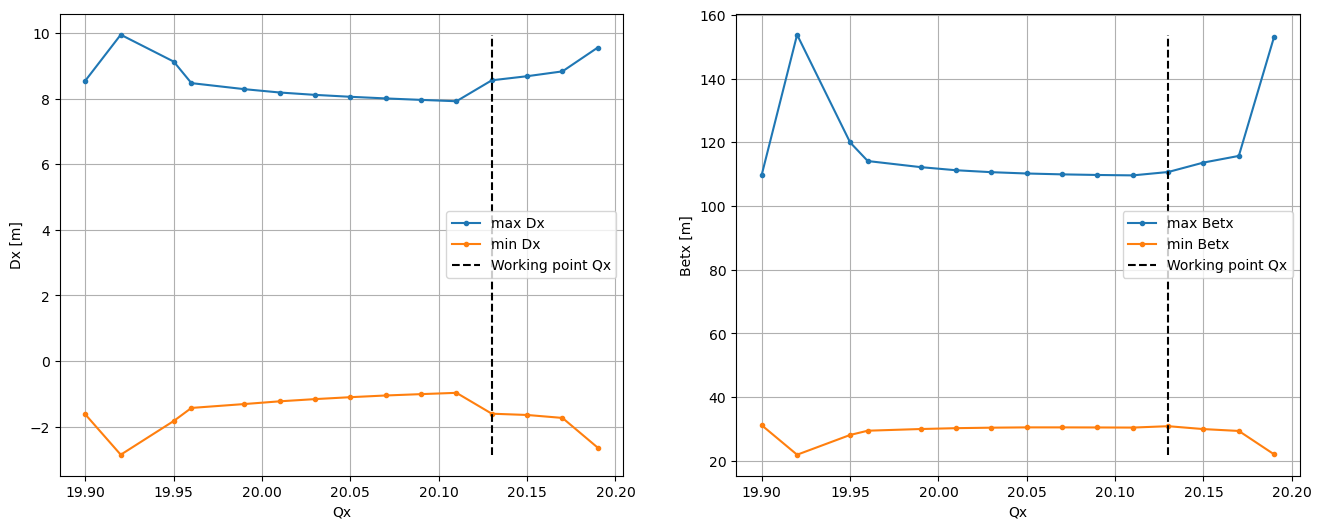

In [52]:
max_vals_dx = []
min_vals_dx = []
max_vals_betx = []
min_vals_betx = []
for twiss in twisses.values():
    max_vals_dx.append(np.max(twiss.dx))
    min_vals_dx.append(np.min(twiss.dx))
    max_vals_betx.append(np.max(twiss.betx))
    min_vals_betx.append(np.min(twiss.betx))

fig, ax = plt.subplots(1,2, figsize=(16,6))
ax[0].plot(tunes_scan, max_vals_dx, marker = '.', label='max Dx')
ax[0].plot(tunes_scan, min_vals_dx, marker = '.', label='min Dx')
ax[0].set_xlabel('Qx')
ax[0].set_ylabel('Dx [m]')
ax[0].vlines(20.13, ymin=min(min_vals_dx), ymax=max(max_vals_dx), color='k', linestyle='--', label='Working point Qx')
ax[0].grid()
ax[0].legend()

ax[1].plot(tunes_scan, max_vals_betx, marker = '.', label='max Betx')
ax[1].plot(tunes_scan, min_vals_betx, marker = '.', label='min Betx')
ax[1].set_xlabel('Qx')
ax[1].set_ylabel('Betx [m]')
ax[1].vlines(20.13, ymin=min(min_vals_betx), ymax=max(max_vals_betx), color='k', linestyle='--', label='Working point Qx')
ax[1].grid()
ax[1].legend()

# Dispersions

In [68]:
def generate_delta_sampling(delta_min, delta_max, step=None, num_points=None):
    if step is None and num_points is None:
        raise ValueError("Either 'step' or 'num_points' must be provided.")
    if step is None:
        step = (delta_max - delta_min) / num_points

    i_min = int(np.ceil(delta_min / step))
    i_max = int(np.floor(delta_max / step))

    arr = step * np.arange(i_min, i_max + 1)
    return arr

In [69]:
def twiss_scan(line, delta_min, delta_max, step=None, num_points=None):
    delta_values = generate_delta_sampling(delta_min, delta_max, step, num_points)
    
    idx_zero = np.where(delta_values == 0)[0][0]
    tw0 = line.twiss4d(delta0=0.0)
    twisses = []
    # twiss_pos.append(tw0)
    # twiss_neg.append(tw0)

    for delta in delta_values[:idx_zero][::-1]:
        twisses.append(line.twiss4d(delta0=delta, co_guess=twisses[-1].particle_on_co) if len(twisses)>0 else tw0)
    twisses = twisses[::-1]
    twisses.append(tw0)
    for delta in delta_values[idx_zero + 1:]:
        twisses.append(line.twiss4d(delta0=delta, co_guess=twisses[-1].particle_on_co))
    
    return delta_values, twisses

In [70]:
line2 = xt.load('../../injection_lines/sps_q20_inj.json')

Loading line from dict:   0%|          | 0/4037 [00:00<?, ?it/s]

Done loading line from dict.           


In [71]:
c = 0.0
qx = 20.13
qy = 10.18
opt = line2.match(
    method='6d', # <- passed to twiss
    vary=[
        xt.VaryList(['kqf0', 'kqd0'], step=1e-8, tag='quad'),
        xt.VaryList(['qph_setvalue', 'qpv_setvalue'], step=1e-4, tag='sext'),
    ],
    targets = [
        xt.TargetSet(qx=qx, qy=qy, tol=1e-6, tag='tune'),
        xt.TargetSet(dqx=c*qx, dqy=c*qy, tol=1e-2, tag='chrom'),
    ])

                                             
Optimize - start penalty: 101.2                             
Matching: model call n. 25 penalty = 2.6401e-04              
Optimize - end penalty:  0.000264007                            


In [72]:
delta_values, twisses = twiss_scan(line2, -1e-2, 1e-2, step = 1e-3)

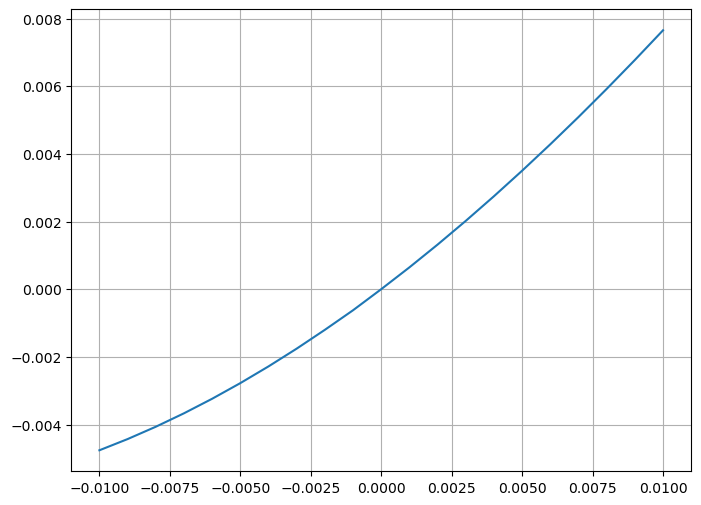

In [83]:
fig, ax = plt.subplots(1, 1, figsize = (8,6))
ax.plot(delta_values, [twiss.rows['qd.52110'].dx[0]*delta_values[i] + twiss.rows['qd.52110'].ddx[0]*delta_values[i]**2 for i, twiss in enumerate(twisses)])
ax.grid()

In [85]:
from scipy.interpolate import interp1d
x = [twiss.rows['qd.52110'].dx[0]*delta_values[i] + twiss.rows['qd.52110'].ddx[0]*delta_values[i]**2 for i, twiss in enumerate(twisses)]
xDdelta = interp1d(delta_values, x, kind="cubic", fill_value="extrapolate")

In [86]:
xDdelta

In [87]:
xDdelta(delta_values)

array([-4.76191211e-03, -4.43100736e-03, -4.06665220e-03, -3.66923230e-03,
       -3.23916660e-03, -2.77690216e-03, -2.28291337e-03, -1.75769809e-03,
       -1.20177717e-03, -6.23045476e-04,  7.63997131e-21,  6.44721698e-04,
        1.31788340e-03,  2.01888183e-03,  2.74710223e-03,  3.50191993e-03,
        4.28270167e-03,  5.08880641e-03,  5.91958756e-03,  6.77439363e-03,
        7.65256913e-03])

In [88]:
dd = np.linspace(-1e-2, 1e-2, 2000)

In [90]:
xDdelta(dd)

array([-0.00476191, -0.00475877, -0.00475562, ...,  0.00763477,
        0.00764367,  0.00765257], shape=(2000,))

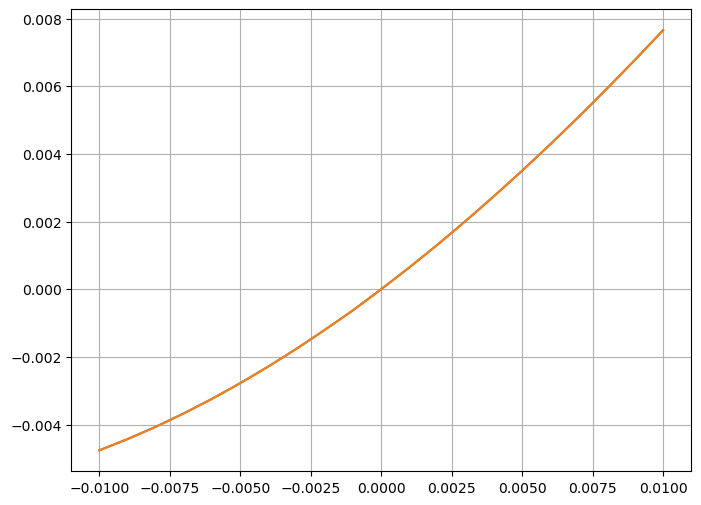

In [91]:
fig, ax = plt.subplots(1, 1, figsize = (8,6))
ax.plot(delta_values, [twiss.rows['qd.52110'].dx[0]*delta_values[i] + twiss.rows['qd.52110'].ddx[0]*delta_values[i]**2 for i, twiss in enumerate(twisses)])
ax.plot(dd, xDdelta(dd))
ax.grid()